In [1]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install os

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


In [4]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install cv2

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [6]:
pip install opencv-python


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import cv2

In [12]:
data =os.listdir( r"C:\Users\HP\OneDrive\Desktop\jupyter1\ML\polynomial linear regression\Brain tumor\Training")
data

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor', 'Yes']

In [9]:
classes = {"Yes" : 1, "no_tumor" : 0}

In [15]:
x=[]
y=[]
for cls in classes:
    path = r"C:/Users/HP/OneDrive/Desktop/jupyter1/ML/polynomial linear regression/Brain tumor/Training/"+cls
    for j in os.listdir(path):
        img=cv2.imread(path+"/"+j, 0)
        img=cv2.resize(img,(200,200))
        x.append(img)
        y.append(classes[cls])
    

In [16]:
np.unique(y)


array([0, 1])

In [17]:
x=np.array(x)

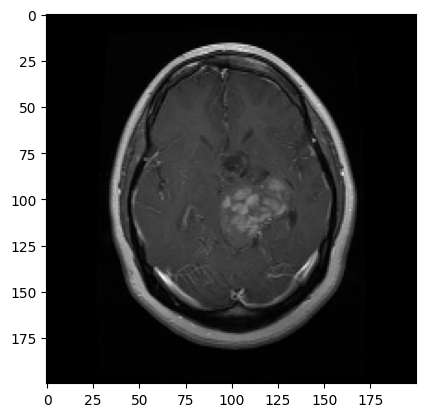

In [18]:
plt.imshow(x[0], cmap="gray")
plt.show()

In [19]:
pd.Series(y).value_counts()

1    2475
0     395
Name: count, dtype: int64

In [20]:
x.shape

(2870, 200, 200)

In [21]:
updated_x=x.reshape(len(x),-1)
updated_x.shape

(2870, 40000)

In [22]:
updated_x[0]

array([0, 0, 0, ..., 0, 0, 0], dtype=uint8)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train ,y_test =train_test_split(updated_x,y,test_size=0.2,random_state=10)

In [25]:
print(type(X_train))
print(type(y_train))


<class 'numpy.ndarray'>
<class 'list'>


In [26]:
y_train = np.array(y_train)
X_train.shape, y_train.shape

((2296, 40000), (2296,))

In [27]:
y_test = np.array(y_test)
X_test.shape, y_test.shape

((574, 40000), (574,))

In [28]:
X=train=X_train/255
X_test=X_test/255

In [29]:
X_train

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [30]:
X_test

array([[0.        , 0.        , 0.        , ..., 0.00392157, 0.00392157,
        0.00392157],
       [0.02745098, 0.02745098, 0.02745098, ..., 0.03137255, 0.03137255,
        0.02745098],
       [0.23921569, 0.1254902 , 0.12941176, ..., 0.00784314, 0.00392157,
        0.11764706],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix

In [32]:
model_name={
    "logistic": LogisticRegression(),
    "Random": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

logistic=0.9163763066202091


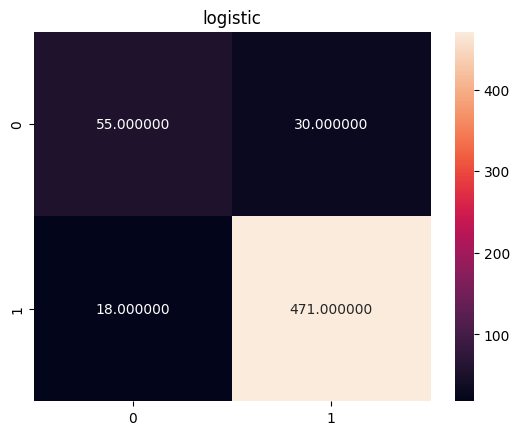

Random=0.1480836236933798


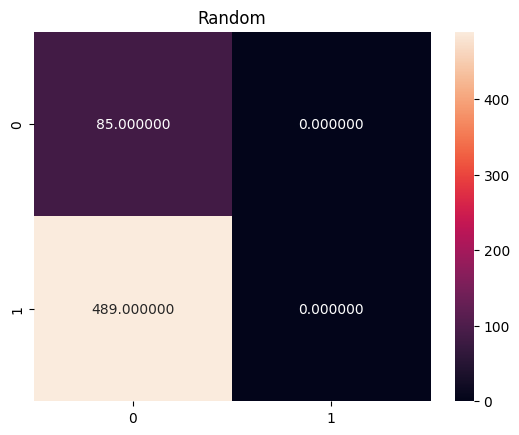

Decision Tree=0.8554006968641115


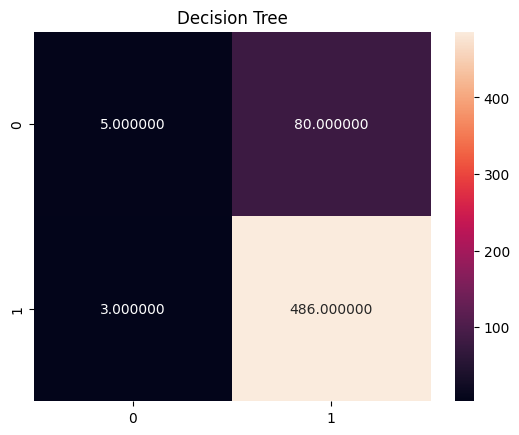

SVM=0.1480836236933798


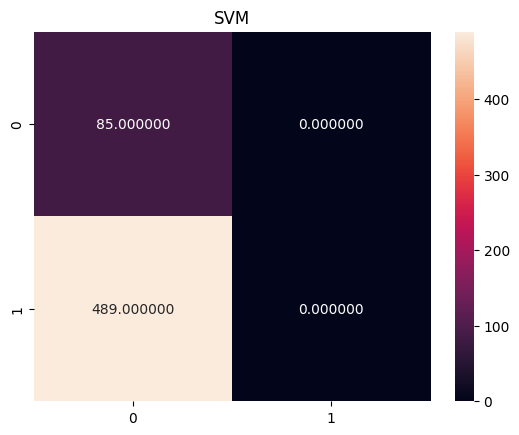

In [33]:
for model_names, model in model_name.items():
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    print(f"{model_names}={accuracy_score(y_test,y_pred)}")
    confusion_mat=confusion_matrix(y_test,y_pred)
    sns.heatmap(confusion_mat,annot=True,fmt="2f")
    plt.title(f"{model_names}")
    plt.show()

In [34]:
random_forest_model=RandomForestClassifier()

In [35]:
random_forest_model.fit(X_train,y_train)

RandomForestClassifier()

In [36]:
print(f"Training Accuracy {random_forest_model.score(X_train,y_train)}")
print(f"Testing Accuracy {random_forest_model.score(X_test, y_test)}")

Training Accuracy 0.9995644599303136
Testing Accuracy 0.1480836236933798


In [37]:
import joblib

In [38]:
joblib.dump(random_forest_model,"Brain_tumor_model.joblib")

['Brain_tumor_model.joblib']

In [39]:
desc={"posittive_Tumor": 1,"No_tumor":0}

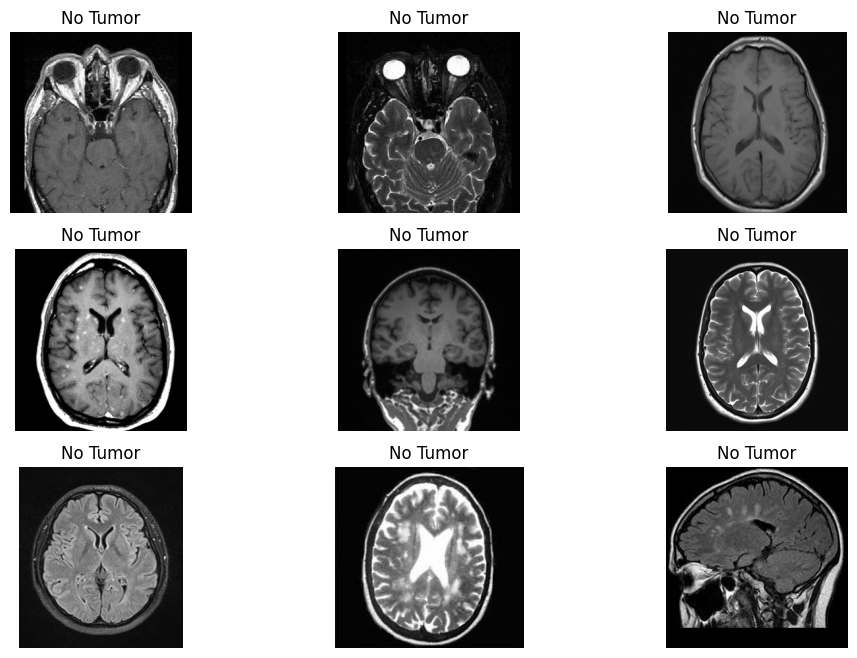

In [40]:
desc = {0: 'No Tumor', 1: 'Tumor'}
new_img = os.listdir(r"C:/Users/HP/OneDrive/Desktop/jupyter1/ML/polynomial linear regression/Brain tumor/Training/no_tumor/")
plt.figure(figsize=(12, 8))
c = 1
for i in new_img[:9]:  
    plt.subplot(3, 3, c)
    img = cv2.imread(r"C:/Users/HP/OneDrive/Desktop/jupyter1/ML/polynomial linear regression/Brain tumor/Training/no_tumor/" + i, 0)
    img1 = cv2.resize(img, (200, 200))
    img1 = img1.reshape(1, -1) / 255 
    p = random_forest_model.predict(img1)
    plt.title(desc[p[0]])
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    c += 1

